In [1]:
from scipy.io import loadmat
import numpy as np
from numpy import *
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pickle
from control import lqr, ss, c2d
from control.matlab import lsim

**The iLQR on the cart and pole system**

Consider the cart-and-pole system here depicted:
<div>
<img src="https://drive.google.com/uc?export=view&id=1Yu5zZ57OEEYZ678yWLaU7h-Wq3M9vV9E" width="200">
</div>
whose dynamics follows the following equations:

\begin{align}
  \ddot{\theta}&=\frac{g \sin(\theta)\,+\,\cos(\theta) \left[ \frac{-F\,-\,m_p\,l\,\dot{\theta}^2 \sin \left(\theta\right)}{m_c\,+\,m_p}\right]-\frac{\mu_p\dot{\theta}}{m_p\,l}}{l\,\left[\frac{4}{3}-\frac{m_p\,cos^2\left(\theta\right)}{m_c\,+\,m_p}\right]}
\end{align}
>>>>>>>>>>>>>>>>>>>>>>>>$(*)$

\begin{align}
  \ddot{p}_c&=\frac{F\,+\,m_p\,l\,\left[\dot{\theta}^2\,\sin\left(\theta\right)\,-\,\ddot{\theta}\,\cos(\theta)\right]}{m_c\,+\,m_p}
\end{align}

where $g = 9.8\,\text{m/sec}$ is the gravitational acceleration, $m_c = 1\,\text{kg}$ is the cart mass, $m_p = 0.1\,\text{kg}$ is the pole mass, $l = 0.5\,\text{m}$ is the half-pole length, $\mu_p = 0.000002$ is the pole on cart friction coefficient.

1. Simulate the non-linear cart and pole system applying the provided control input sequence $\bar{u}^{(k)}$ with a sample time of 0.005 sec. Record the resulting state trajectory $\bar{x}^{(k)}$ with an initial state of $\theta=180^°$, $\dot{\theta}=0$, $p_c=0$, $\dot{p_c}=0$. Plot the resulting trajectory.


In [2]:
g = 9.8 # gravitational acceleration
mc = 1  # cart mass [kg]
l = 0.5 # half-pole length [m]
m = 0.1 # pole mass [kg]
miup = 2e-6 # pole friction coefficient

# let's set the input force to 0
F = 0 # N

In [3]:
def cart_and_pole_odeint(x, t, F):
  dxdt = np.zeros_like(x)

  dxdt[0] = x[1] #tetap
  dxdt[1] = (g*sin(x[0])+ cos(x[0])*((-F-m*l*(x[1]**2)*sin(x[0]))/(mc+m))-((miup*x[1])/(m*l))) / (l*((4/3)-((m*(cos(x[0])**2))/(mc+m))))    #teta2p
  dxdt[2] = x[3] #xp
  dxdt[3] = (F+m*l*((x[1]**2)*sin(x[0])-dxdt[1]*cos(x[0])))/(mc+m) #x2p
  return dxdt

In [4]:
uvec = loadmat('ilqr_u.mat')
uvec = uvec['input_traj'].T[0]

In [5]:
time_step=0.005
t0_odeint=0
x0_odeint = np.array([np.pi, 0.0, 0.0, 0.0])
X_odeint=[x0_odeint]

In [6]:
for i in range(len(uvec)):
    t1_odeint = t0_odeint+0.02
    t_odeint = np.array([t0_odeint, t1_odeint])
    F = uvec[i]
    x_odeint = odeint(cart_and_pole_odeint, x0_odeint, t_odeint, args=(F, ))
    x0_odeint = x_odeint[1]
    X_odeint=np.append(X_odeint, [x0_odeint], axis= 0)

Text(0.5, 1.0, 'p_c(t)')

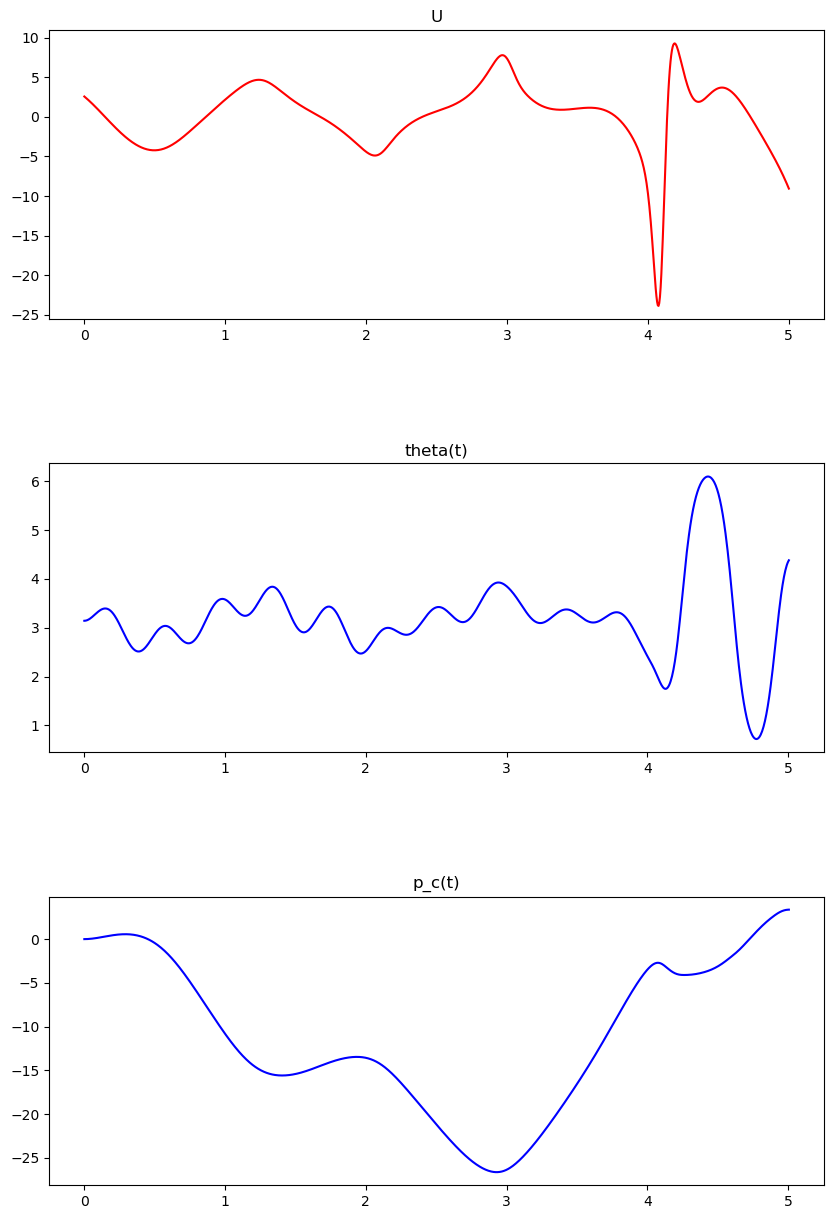

In [7]:
time_sim=np.arange(0.0, 5+2*time_step, time_step)

plt.rcParams['figure.figsize'] = [10, 15]
fig, axs = plt.subplots(3)
fig.subplots_adjust(hspace=0.5)

axs[0].plot(time_sim[:-1], uvec, 'r', label='U(t)')
axs[0].set_title("U")

axs[1].plot(time_sim, X_odeint[:,0], 'b')
axs[1].set_title("theta(t)")

axs[2].plot(time_sim, X_odeint[:,2], 'b')
axs[2].set_title("p_c(t)")

2. Linearize the non-linear cart and pole system around the nominal state-input trajectories $\{\bar{x}^{(k)},\bar{u}^{(k)}\}$ previously obtained, and store the time-varying matrices of the linearized system $\{A(k),B(k)\}$




In [8]:
import sympy as sym
from sympy import sin, cos

In [9]:
x1 = sym.Symbol("x1")
x2 = sym.Symbol("x2")
x3 = sym.Symbol("x3")
x4 = sym.Symbol("x4")
F = sym.Symbol("F")
x = [x1,x2,x3,x4]
theta2p = ((g*sin(x[0]))+(cos(x[0])*((-F-(m*l*(x[1]**2)*sin(x[0])))/(mc+m)))-((miup*x[1])/(m*l)))/(l*((4/3)-((m*((cos(x[0]))**2))/(mc+m))))
x2p = (F+(m*l*(((x[1]**2)*sin(x[0]))-((((g*sin(x[0]))+(cos(x[0])*((-F-(m*l*(x[1]**2)*sin(x[0])))/(mc+m)))-((miup*x[1])/(m*l)))/(l*((4/3)-((m*((cos(x[0]))**2))/(mc+m)))))*cos(x[0])))))/(mc+m)

A_history = []
B_history = []

In [10]:
for k in range(len(uvec)):
    xeq = X_odeint[k]
    ueq = uvec[k]

    theta2p_linA = []
    for i in range(len(x)): # for each state variable
        lin = sym.diff(theta2p, x[i]) # evaluate the partial derivative
        lin = lin.subs(F, ueq)
        for j in range(len(x)):
            lin = lin.subs(x[j], xeq[j]) # replace equilibrium points
        theta2p_linA.append(lin)
    
    theta2p_linB = sym.diff(theta2p, F)
    for j in range(len(x)):
        theta2p_linB = theta2p_linB.subs(x[j], xeq[j]) # replace equilibrium points
    theta2p_linB.subs(F, ueq)
    
    x2p_linA = []
    for i in range(len(x)):
        lin = sym.diff(x2p, x[i]) # evaluate the partial derivative
        lin = lin.subs(F, ueq)
        for j in range(len(x)):
            lin = lin.subs(x[j], xeq[j]) # replace equilibrium points
        x2p_linA.append(lin)
    
    x2p_linB = sym.diff(x2p, F)
    for j in range(len(x)):
        x2p_linB = x2p_linB.subs(x[j], xeq[j]) # replace equilibrium points
    x2p_linB.subs(F, ueq)
    
    A = np.array([
        [0, 1, 0, 0],
        theta2p_linA,
        [0, 0, 0, 1],
        x2p_linA
    ])
    
    B = np.array([
        [0],
        [theta2p_linB],
        [0],
        [x2p_linB]
    ])
    
    A_history.append(A)
    B_history.append(B)

In [11]:
C = np.eye(4)
D = np.zeros(4).reshape(4,1)

3. Compute the discrete-time homogeneous representation of the linear time-varying cart and pole system obtained at point 2. and store the matrices of the homogeneous representation



In [12]:
A_history[0]

array([[0, 1, 0, 0],
       [-15.7756097560976, -6.43902439024390e-5, 0, 0],
       [0, 0, 0, 1],
       [-0.717073170731708, -2.92682926829268e-6, 0, 0]], dtype=object)

In [13]:
A_history[-1]

array([[0, 1, 0, 0],
       [7.40510575002901, -0.0685051413441005, 0, 0],
       [0, 0, 0, 1],
       [0.860954307505454, -0.129845415951059, 0, 0]], dtype=object)

In [14]:
A_history_d = []
B_history_d = []

In [15]:
for i in range(len(A_history)):
    S = ss(A_history[i], B_history[i], C, D)
    S_d = c2d(S, time_step)
    
    A_history_d.append(S_d.A)
    B_history_d.append(S_d.B)

4.    Assume $Q=I$ and $R=1$ , the cost matrices for a swing up cart and pole task, and compute $\hat{Q}(k)=\begin{bmatrix}
Q & -q^{{(k)}^\top}\\
-q^{(k)} & d^{(k)}\end{bmatrix}$ where $\bar{x}^{{(k)}^\top} Q \bar{x}^{(k)}=d^{(k)}$ and $2\bar{x}^{{(k)}^\top} Q=2 q^{{(k)}^\top}$ for the entire nominal state trajectory  and store them

In [16]:
Q = np.eye(4,4)
R = 1

In [17]:
Q_hat_history = []

for i in range(len(uvec)):
    d_k = (X_odeint[i]*Q*X_odeint[i][np.newaxis].T)[0][0]
    q_k = (X_odeint[i]*Q)[0]
    Q_hat = np.concatenate([
        np.concatenate((Q, -q_k[np.newaxis].T), axis=1),
        [np.concatenate([-q_k,    [d_k]], axis=0)]
    ], axis=0)

    sym_check = np.array_equal(Q_hat, Q_hat.T) # check the simmetry of the matrix Q_hat
    ispos = np.all(np.linalg.eigvals(Q_hat) > 0)
    ep = 10e-6;

    while not ispos:
        Q_hat = Q_hat + ep*np.eye(5,5);
        ispos = np.all(np.linalg.eigvals(Q_hat) > 0)
        ep = 10*ep;
    
    Q_hat_history.append(Q_hat)

5.   Solve the finite-horizon LQR problem on the linearized version of the system and store the control gain matrices $\{K(k)\}$. Assume that $P_H=\begin{bmatrix}
I &0\\0 &0\end{bmatrix}$.

Qualcosa qua sotto non va:

dispense pag 380

In [18]:
P_h = np.concatenate([
    np.concatenate([np.eye(4), np.zeros((4,1))], axis=1),
    np.zeros((1, 5))
], axis=0)

A_riccati = np.concatenate([
    np.concatenate([A_history_d[-1], np.zeros((4,1))], axis=1),
    np.concatenate([np.zeros((1,4)), [[1]]], axis=1)
], axis=0)

B_riccati = np.concatenate([B_history_d[-1], [[0]]], axis=0)
 
Q_cinque = Q_hat_history[-1]
 
P_k = A_riccati.T * P_h * A_riccati + Q_cinque - A_riccati.T * P_h * B_riccati * (np.linalg.inv(R + B_riccati.T * P_h * B_riccati)) * B_riccati.T * P_h * A_riccati
K_k = (np.linalg.inv(R + B_riccati.T * P_h * B_riccati)) * B_riccati.T * P_h * A_riccati
K_k_history = [K_k]
           
for i in reversed(range(999)):
    
    A_riccati = np.concatenate([
        np.concatenate([A_history_d[i], np.zeros((4,1))], axis=1),
        np.zeros((1,5))
    ], axis=0)
    B_riccati = np.concatenate([B_history_d[i], [[0]]], axis=0)
    
    Q_cinque = Q_hat_history[i]
    P_k_uno = P_k;

    P_k = A_riccati.T * P_h * A_riccati + Q_cinque - A_riccati.T * P_h * B_riccati * (np.linalg.inv(R + B_riccati.T * P_h * B_riccati)) * B_riccati.T * P_h * A_riccati
    K_k = (np.linalg.inv(R + B_riccati.T * P_h * B_riccati)) * B_riccati.T * P_h * A_riccati
    
    K_k_history.append(K_k)

In [19]:
B_history_d[-1]

matrix([[6.04035882e-06],
        [2.41604288e-03],
        [1.14588356e-05],
        [4.58327716e-03]])

6. Simulate the non-linear cart and pole system applying the computed control gain matrices $\{K(k)\}$ with a sample time of 0.005 sec. Record the resulting state and control input trajectory with an initial state of $\theta=180^°$, $\dot{\theta}=0$, $p_c=0$, $\dot{p_c}=0$. Plot the resulting trajectories

In [20]:
x0_odeint = np.array([np.pi, 0, 0, 0])
x_hat = np.concatenate([
    x0_odeint - (X_odeint[0]),
    [1]
], axis=0).reshape(5,1)

U = -K_k_history[0]*x_hat

X_odeint_lin = []

uvec = np.zeros(1000)
uvec[0] = U

for i in range(len(uvec)):
    t1_odeint = t0_odeint+0.02
    t_odeint = np.array([t0_odeint, t1_odeint])
    F = uvec[i]
    
    x_odeint = odeint(cart_and_pole_odeint, x0_odeint, t_odeint, args=(F, ))
    X_odeint_lin.append(x0_odeint)
    
    x0_odeint = x0_odeint - X_odeint[i+1]
    
    if i < len(uvec)-1:
        uvec[i+1] = -(K_k_history[i+1] * np.append(x_odeint[1], [1], axis=0)[np.newaxis].T)[0][0]

X_odeint_lin = np.array(X_odeint_lin)

Text(0.5, 1.0, 'p_c(t)')

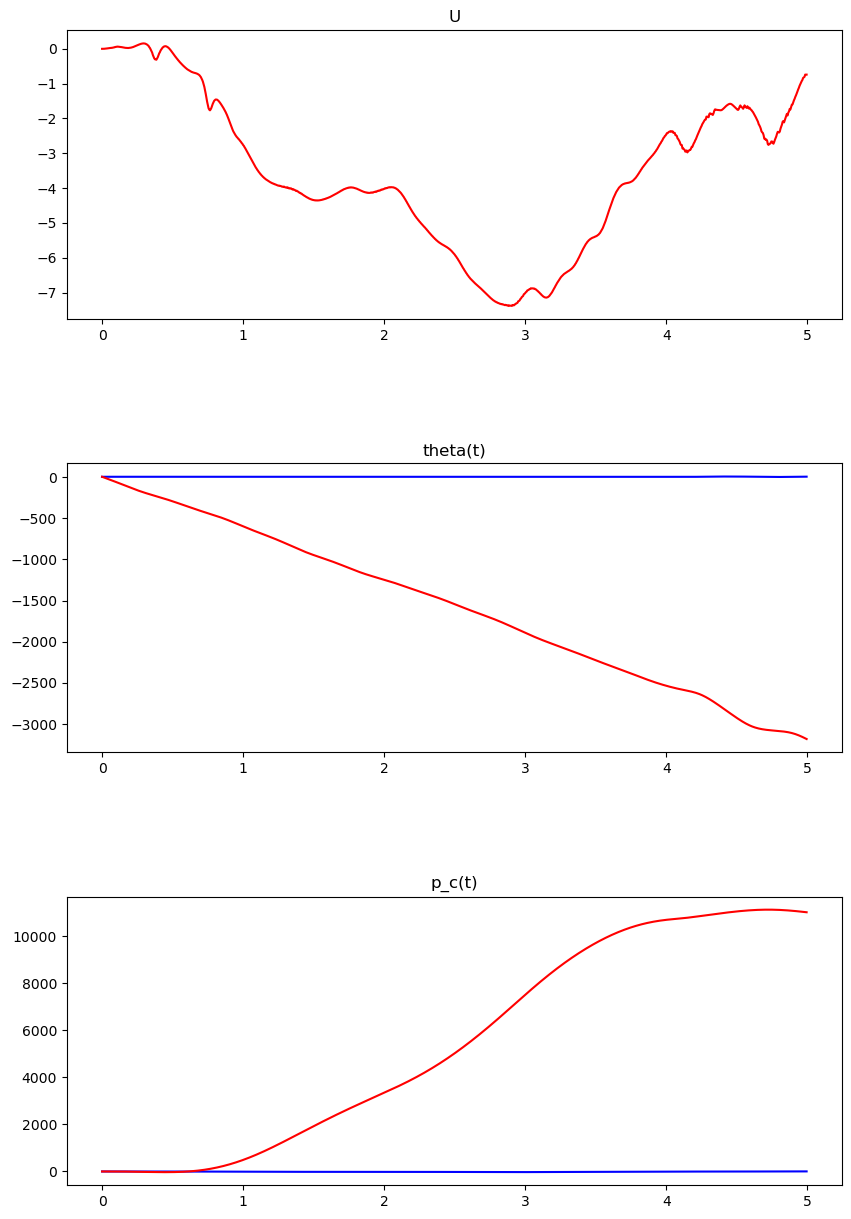

In [21]:
time_sim=np.arange(0.0, 5, time_step)

plt.rcParams['figure.figsize'] = [10, 15]
fig, axs = plt.subplots(3)
fig.subplots_adjust(hspace=0.5)

axs[0].plot(time_sim, uvec, 'r', label='U(t)')
axs[0].set_title("U")

axs[1].plot(time_sim, X_odeint[:-2,0], 'b')
axs[1].plot(time_sim, X_odeint_lin[:,0], 'r')
axs[1].set_title("theta(t)")

axs[2].plot(time_sim, X_odeint[:-2,2], 'b')
axs[2].plot(time_sim, X_odeint_lin[:,2], 'r')
axs[2].set_title("p_c(t)")